📁 All output images will be saved in the 'outputs/' folder.
✅ Dataset loaded successfully. Shape: (1372, 5)
   variance  skewness  curtosis  entropy  class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0
Training samples: 1097, Testing samples: 275

(1) Accuracy without L2 Regularization: 0.9855
(2) Accuracy with L2 Regularization: 0.9709


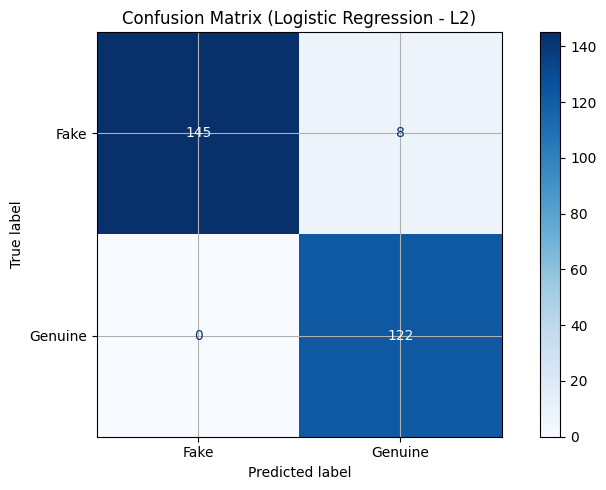

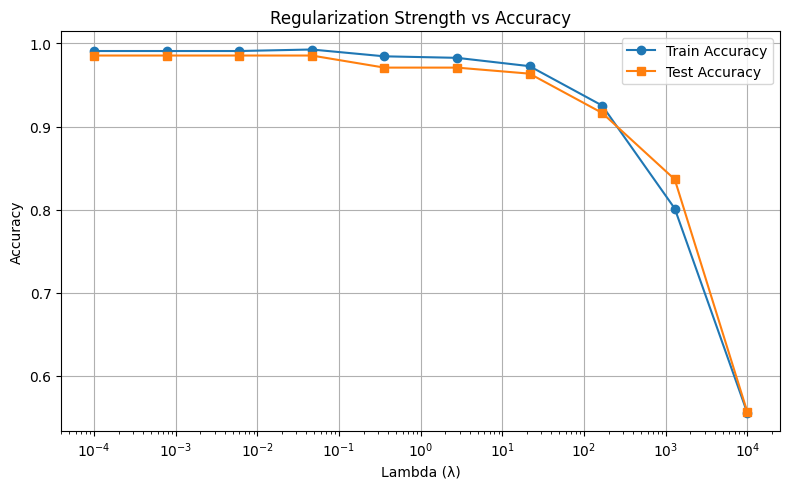


Accuracy before Outliers: 0.9709
Accuracy after Outliers: 0.9745


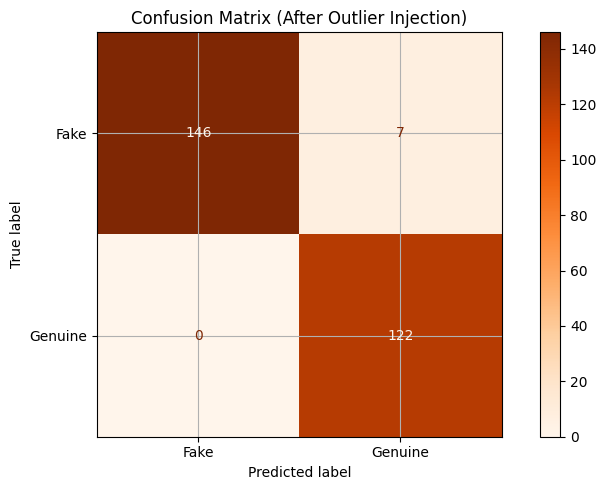


Model Performance Summary:
            Model  Accuracy
0      Without L2  0.985455
1         With L2  0.970909
2  After Outliers  0.974545

✅ All plots saved successfully in 'outputs/' folder.


In [1]:
# ============================================================
# ICS1502 - Introduction to Machine Learning
# Assignment 1.2 - Linear Classification: Bank Note Authentication
# ============================================================

# --- Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from mpl_toolkits.mplot3d import Axes3D
import os

# ---------------------- Setup ----------------------
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
np.random.seed(42)

# Create output directory
os.makedirs("outputs", exist_ok=True)
print("📁 All output images will be saved in the 'outputs/' folder.")

# ============================================================
# STEP 1: Load Dataset (from Kaggle)
# ============================================================
# Dataset: https://www.kaggle.com/datasets/ritesaluja/bank-note-authentication-uci-data
# File name: data_banknote_authentication.csv

data = pd.read_csv("/content/BankNote_Authentication.csv")
print("✅ Dataset loaded successfully. Shape:", data.shape)
print(data.head())

X = data.drop("class", axis=1)
y = data["class"]

# ============================================================
# STEP 2: Split Data into Training and Testing Sets
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

# ============================================================
# STEP 3: Standardization
# ============================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================================
# STEP 4: Logistic Regression (Without and With L2 Regularization)
# ============================================================

# Without Regularization (use very large C to approximate penalty='none')
clf_none = LogisticRegression(penalty='l2', C=1e10, max_iter=1000)
clf_none.fit(X_train_scaled, y_train)
y_pred_none = clf_none.predict(X_test_scaled)
acc_none = accuracy_score(y_test, y_pred_none)

# With Regularization (L2)
clf_l2 = LogisticRegression(penalty='l2', C=1.0, max_iter=1000)
clf_l2.fit(X_train_scaled, y_train)
y_pred_l2 = clf_l2.predict(X_test_scaled)
acc_l2 = accuracy_score(y_test, y_pred_l2)

print(f"\n(1) Accuracy without L2 Regularization: {acc_none:.4f}")
print(f"(2) Accuracy with L2 Regularization: {acc_l2:.4f}")

# Confusion Matrix (L2)
cm = confusion_matrix(y_test, y_pred_l2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fake", "Genuine"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (Logistic Regression - L2)")
plt.tight_layout()
plt.savefig("outputs/confusion_matrix_banknote.png", dpi=300)
plt.show()

# ============================================================
# STEP 5: Accuracy vs Regularization Strength (λ)
# ============================================================
lambdas = np.logspace(-4, 4, 10)
train_acc, test_acc = [], []

for lam in lambdas:
    clf = LogisticRegression(penalty='l2', C=1/lam, max_iter=1000)
    clf.fit(X_train_scaled, y_train)
    train_acc.append(clf.score(X_train_scaled, y_train))
    test_acc.append(clf.score(X_test_scaled, y_test))

plt.figure()
plt.semilogx(lambdas, train_acc, marker='o', label='Train Accuracy')
plt.semilogx(lambdas, test_acc, marker='s', label='Test Accuracy')
plt.xlabel("Lambda (λ)")
plt.ylabel("Accuracy")
plt.title("Regularization Strength vs Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/accuracy_vs_lambda.png", dpi=300)
plt.show()


# ============================================================
# STEP 7: Outlier Injection
# ============================================================
X_outlier = X.copy()
X_outlier.iloc[:10, 0] += 10   # add extreme values to variance
X_outlier.iloc[:10, 1] -= 8
y_outlier = y.copy()

# Re-train model on outlier data
X_train_o, X_test_o, y_train_o, y_test_o = train_test_split(
    X_outlier, y_outlier, test_size=0.2, stratify=y_outlier, random_state=42
)
X_train_o_scaled = scaler.fit_transform(X_train_o)
X_test_o_scaled = scaler.transform(X_test_o)

clf_outlier = LogisticRegression(penalty='l2', C=1.0, max_iter=1000)
clf_outlier.fit(X_train_o_scaled, y_train_o)
y_pred_outlier = clf_outlier.predict(X_test_o_scaled)

acc_outlier = accuracy_score(y_test_o, y_pred_outlier)
print(f"\nAccuracy before Outliers: {acc_l2:.4f}")
print(f"Accuracy after Outliers: {acc_outlier:.4f}")

# Confusion Matrix (After Outliers)
cm_out = confusion_matrix(y_test_o, y_pred_outlier)
disp_out = ConfusionMatrixDisplay(confusion_matrix=cm_out, display_labels=["Fake", "Genuine"])
disp_out.plot(cmap="Oranges")
plt.title("Confusion Matrix (After Outlier Injection)")
plt.tight_layout()
plt.savefig("outputs/confusion_matrix_outlier.png", dpi=300)
plt.show()

# ============================================================
# STEP 8: Summary Table
# ============================================================
summary = pd.DataFrame({
    "Model": ["Without L2", "With L2", "After Outliers"],
    "Accuracy": [acc_none, acc_l2, acc_outlier]
})
print("\nModel Performance Summary:")
print(summary)

# ============================================================
# END OF ASSIGNMENT 1.2
# ============================================================

print("\n✅ All plots saved successfully in 'outputs/' folder.")
